In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Complex_ms\..


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [ ]:
phase_methods = [
    md.get_phase_maxpoint,
    md.get_phase_zero_crossings,
    md.get_phase_FFT,
    md.get_phase_hilbert,
    md.get_phase_xcor_zoom,
    md.get_phase_lockin,
    md.get_phase_swf3p,
    md.get_phase_swff4p,
    md.get_phase_swfr
]

In [37]:
# Параметры
F_main_real = 4e5
phase_real = 30
fs_mult = 10
gen_unstable = 5 # HZ
SNR = 60 # dB

method_diffs=[]
for method in phase_methods:

    phases_diff=[]
    for duration_T in range(int(3),int(100),int(1)):
        # Временная сетка
        duration = duration_T / F_main_real
        fs = F_main_real * fs_mult
        t = np.linspace(0, duration, int(duration * fs))

        # 1. Общая фаза
        phase = md.generate_common_phase(
            t,
            F_main_real,
            gen_unstable,
            phase0_deg=0
        )

        # 2. Сигналы с заданной фазовой разницей
        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        # 3. Добавляем шум
        #U = md.add_SNR(U, SNR)
        #I = md.add_SNR(I, SNR)
        phase_est=method(t,I,U,F_main_real)
        div=abs(phase_real-phase_est)
        phases_diff.append(div)

    method_diffs.append(phases_diff)

In [36]:
method_diffs[3]

[np.float64(0.08575041361677904),
 np.float64(0.0038570454702977486),
 np.float64(0.0068417200123676025),
 np.float64(0.004342139415179247),
 np.float64(0.0030976534936897338),
 np.float64(0.0023426209138506238),
 np.float64(0.001860472186265838),
 np.float64(0.0015189182853205807),
 np.float64(0.001262028817045291),
 np.float64(0.0010548779926509155)]

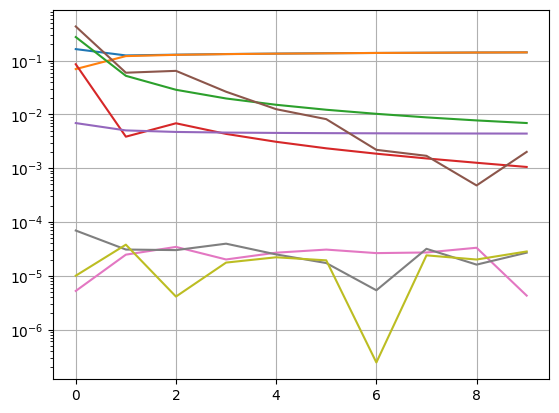

In [28]:
for i in range(0,len(method_diffs),1):
    plt.plot(method_diffs[i])
plt.grid(True)
plt.yscale('log')